In [1]:
import pandas as pd
import numpy as np

# Загружаем ваш Excel-файл
df = pd.read_excel('coursework_ml_data.xlsx')

# Проверяем размерность (должно быть 1000 на 213)
print(f"Размер датасета: {df.shape}")


Размер датасета: (1001, 214)


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 214 entries, Unnamed: 0 to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.6 MB


In [3]:
df.columns

Index(['Unnamed: 0', 'IC50, mM', 'CC50, mM', 'SI', 'MaxAbsEStateIndex',
       'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS',
       ...
       'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene',
       'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene',
       'fr_unbrch_alkane', 'fr_urea'],
      dtype='str', length=214)

In [4]:
df[['IC50, mM', 'CC50, mM', 'SI']].describe()

,"IC50, mM","CC50, mM",SI
count,1001.000000,1001.000000,1001.000000
mean,222.805156,589.110728,72.508823
std,402.169734,642.867508,684.482739
min,0.003517,0.700808,0.011489
25%,12.515396,99.999036,1.433333
50%,46.585183,411.039342,3.846154
75%,224.975928,894.089176,16.566667
max,4128.529377,4538.976189,15620.600000


In [5]:
df.head(3).T

,0,1,2
Unnamed: 0,0.000000,1.000000,2.000000
"IC50, mM",6.239374,0.771831,223.808778
"CC50, mM",175.482382,5.402819,161.142320
SI,28.125000,7.000000,0.720000
MaxAbsEStateIndex,5.094096,3.961417,2.627117
...,...,...,...
fr_thiazole,0.000000,0.000000,0.000000
fr_thiocyan,0.000000,0.000000,0.000000
fr_thiophene,0.000000,0.000000,0.000000
fr_unbrch_alkane,3.000000,3.000000,3.000000


Удаляем столбец 'Unnamed: 0'...
Новая размерность: (1001, 213)


/tmp/ipykernel_110795/2881177939.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{target}_log'] = np.log1p(df[target])


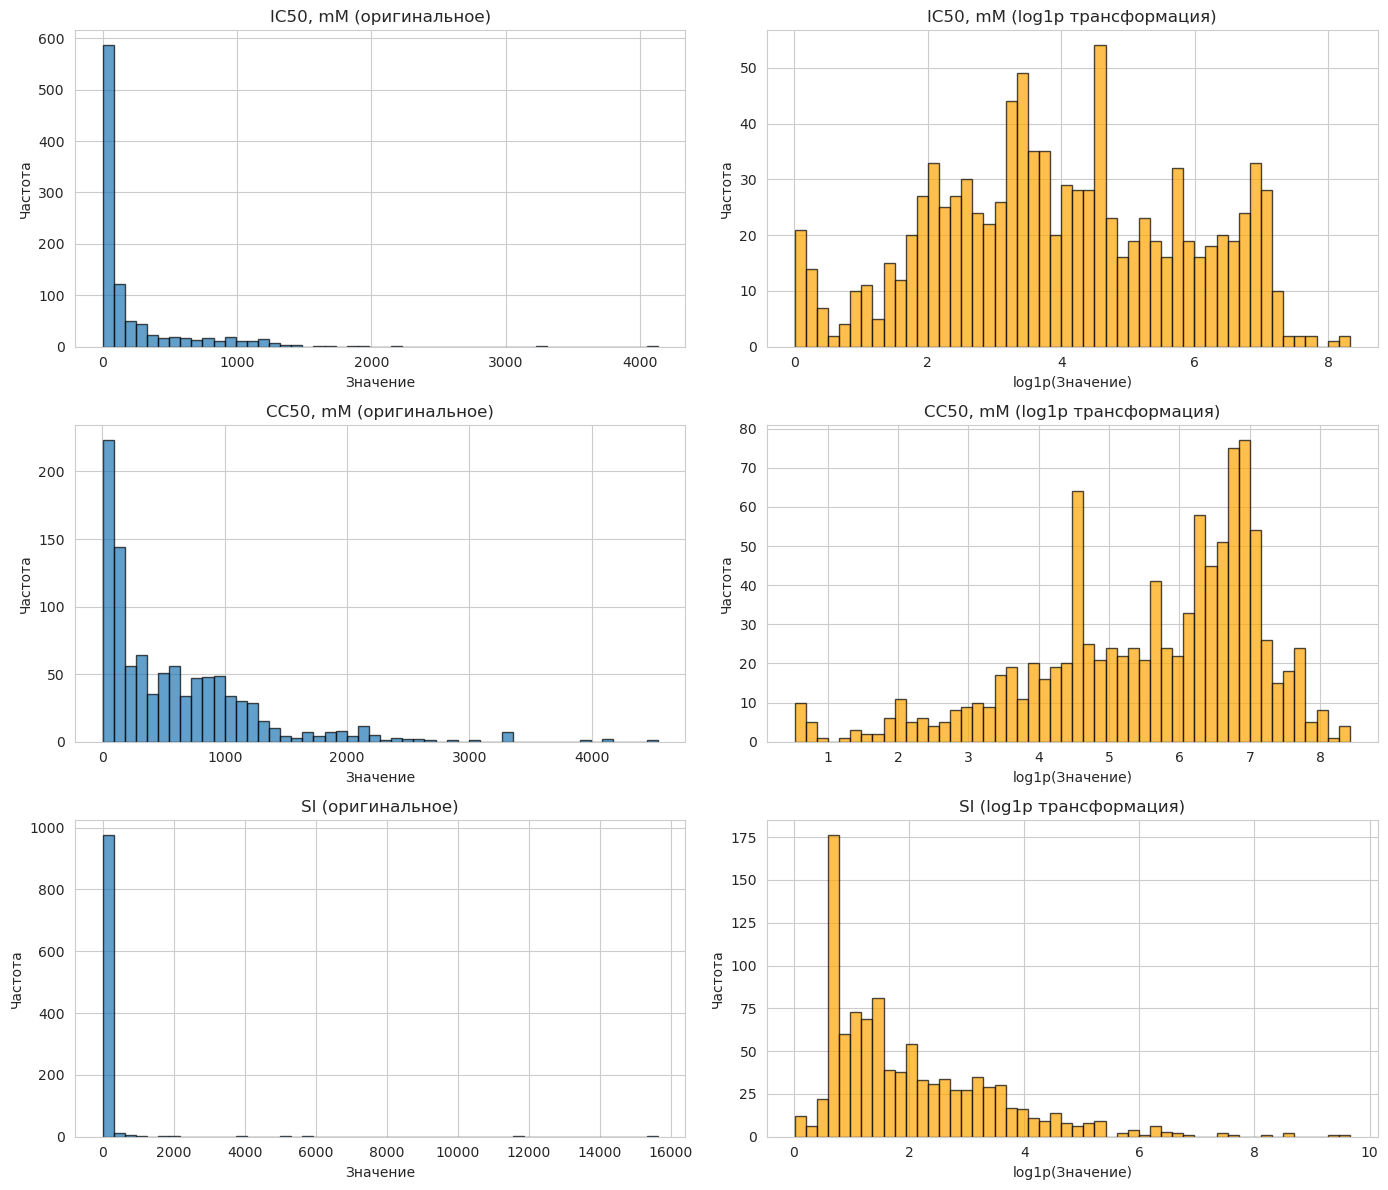


СТАТИСТИКА ТАРГЕТНЫХ ПЕРЕМЕННЫХ

IC50, mM:
  Оригинал:  mean=222.81, std=402.17, skew=3.67
  Log1p:     mean=3.98, std=1.86, skew=-0.03

CC50, mM:
  Оригинал:  mean=589.11, std=642.87, skew=1.97
  Log1p:     mean=5.57, std=1.59, skew=-0.91

SI:
  Оригинал:  mean=72.51, std=684.48, skew=18.01
  Log1p:     mean=2.04, std=1.46, skew=1.43

АНАЛИЗ КОРРЕЛЯЦИЙ

Топ-10 признаков с наибольшей корреляцией с SI:
BalabanJ            0.162955
fr_NH2              0.160470
RingCount           0.124444
fr_Al_COO           0.102414
fr_COO2             0.101115
fr_COO              0.101115
NumAromaticRings    0.088064
VSA_EState4         0.087837
FpDensityMorgan1    0.087341
VSA_EState6         0.082995
dtype: float64


/home/itj/anaconda3/envs/edu/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/itj/anaconda3/envs/edu/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


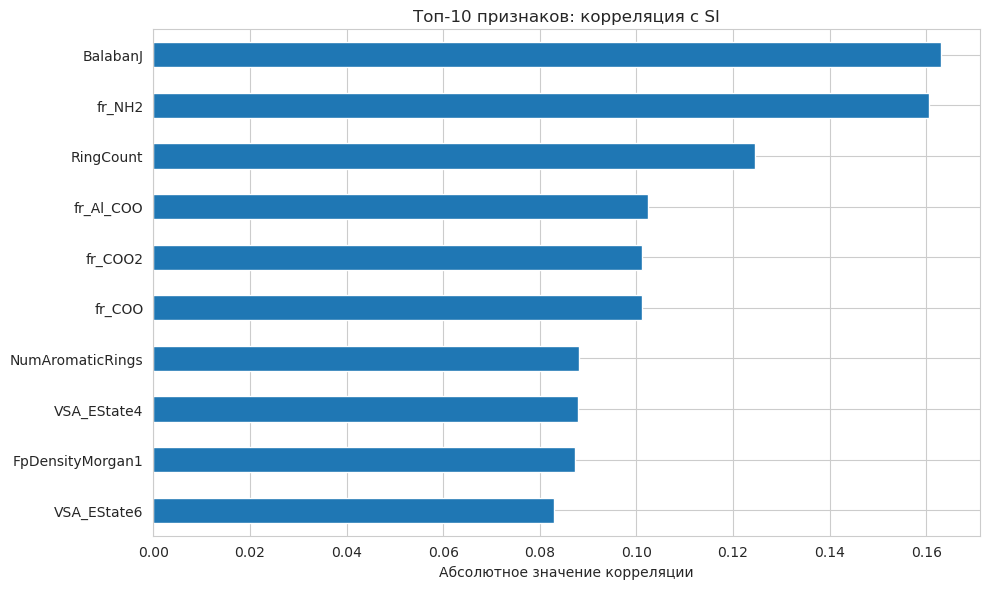

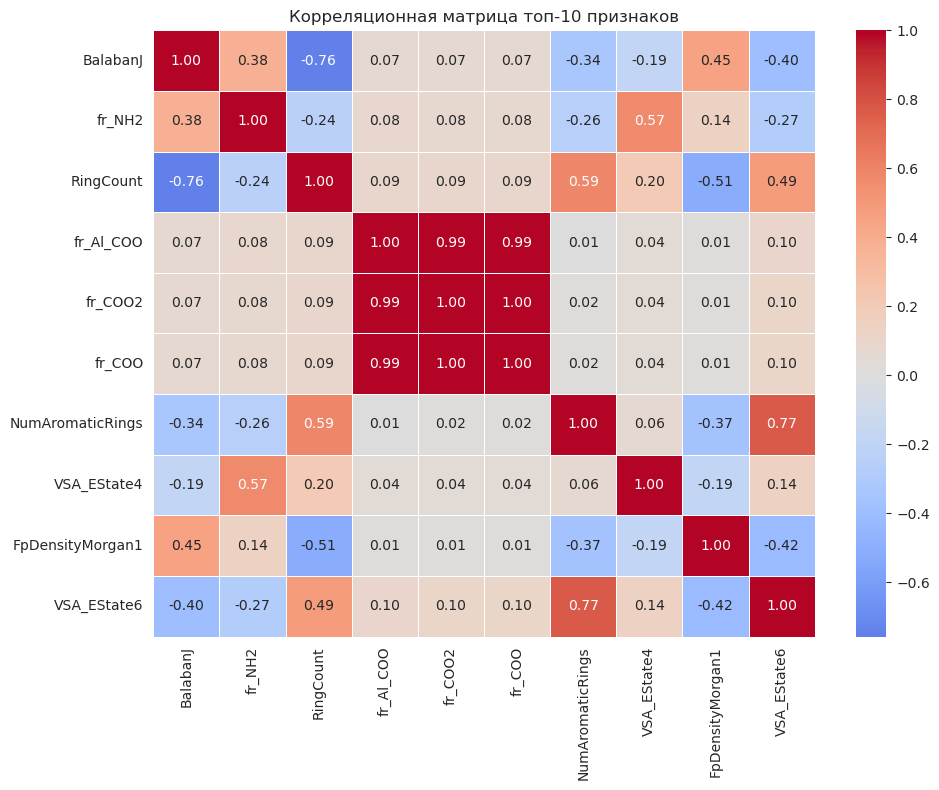


Пары признаков с корреляцией > 0.9: 154
  MaxEStateIndex: 1.000
  HeavyAtomMolWt: 0.997
  ExactMolWt: 1.000
  ExactMolWt: 0.997
  NumValenceElectrons: 0.981
  NumValenceElectrons: 0.966
  NumValenceElectrons: 0.981
  MaxAbsPartialCharge: 0.922
  MinAbsPartialCharge: 0.975
  FpDensityMorgan2: 0.948

БАЛАНС КЛАССОВ ДЛЯ КЛАССИФИКАЦИИ

Медиана SI: 3.85
Распределение по медиане (SI > 3.85):
SI_class_median
0    501
1    500
Name: count, dtype: int64
Доля класса 1: 50.0%

Порог SI = 8:
SI_class_8
0    644
1    357
Name: count, dtype: int64
Доля класса 1 (SI > 8): 35.7%


/tmp/ipykernel_110795/2881177939.py:110: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['SI_class_median'] = (df['SI'] > median_si).astype(int)
/tmp/ipykernel_110795/2881177939.py:119: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['SI_class_8'] = (df['SI'] > threshold_si).astype(int)
/tmp/ipykernel_110795/2881177939.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data

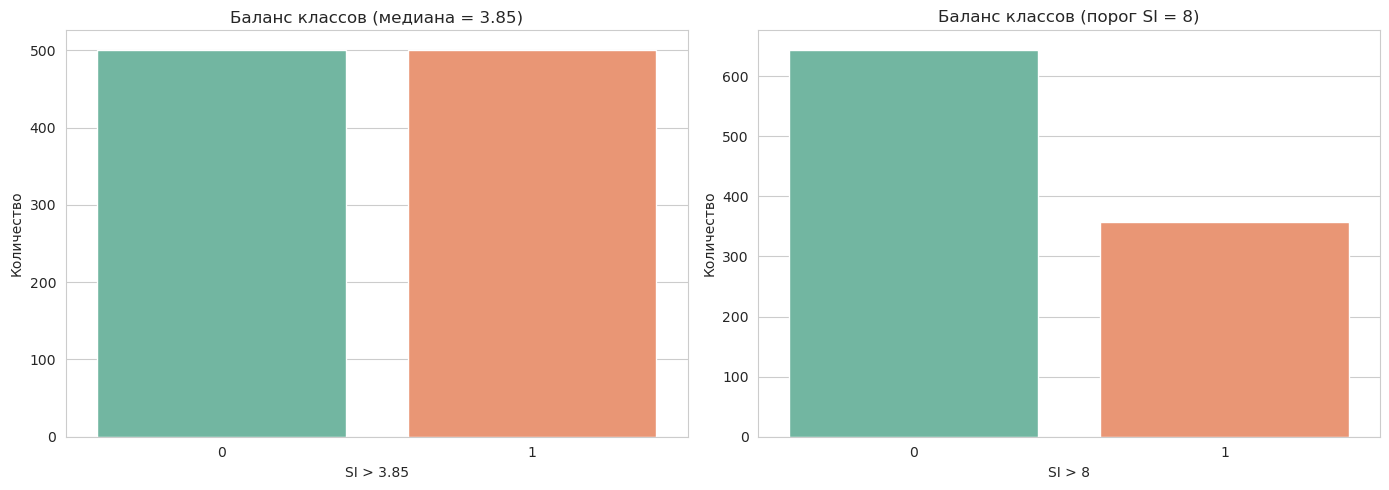


Распределение IC50 для классификации:
Медиана IC50: 46.59
IC50_class
0    501
1    500
Name: count, dtype: int64

EDA ЗАВЕРШЕН!

Рекомендации:
1. Использовать log1p трансформацию для всех таргетов
2. Учесть сильную мультиколлинеарность (при need удалить коррелирующие признаки)
3. Для классификации SI > 8: дисбаланс классов = 35.7% положительных
4. Топ-10 признаков для SI: BalabanJ, fr_NH2, RingCount, fr_Al_COO, fr_COO2...


/tmp/ipykernel_110795/2881177939.py:146: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['IC50_class'] = (df['IC50, mM'] > median_ic50).astype(int)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Настройка стиля графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ============================================================================
# 1. Удаление лишнего столбца
# ============================================================================
print("Удаляем столбец 'Unnamed: 0'...")
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
print(f"Новая размерность: {df.shape}")

# ============================================================================
# 2. Анализ распределений таргетных переменных
# ============================================================================
targets = ['IC50, mM', 'CC50, mM', 'SI']

# Создаем фигуру с графиками
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for idx, target in enumerate(targets):
    # Оригинальное распределение
    axes[idx, 0].hist(df[target], bins=50, edgecolor='black', alpha=0.7)
    axes[idx, 0].set_title(f'{target} (оригинальное)')
    axes[idx, 0].set_xlabel('Значение')
    axes[idx, 0].set_ylabel('Частота')
    
    # Логарифмированное распределение (добавляем small constant для нулей)
    df[f'{target}_log'] = np.log1p(df[target])
    axes[idx, 1].hist(df[f'{target}_log'], bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[idx, 1].set_title(f'{target} (log1p трансформация)')
    axes[idx, 1].set_xlabel('log1p(Значение)')
    axes[idx, 1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

# Статистика до и после логарифмирования
print("\n" + "="*80)
print("СТАТИСТИКА ТАРГЕТНЫХ ПЕРЕМЕННЫХ")
print("="*80)
for target in targets:
    print(f"\n{target}:")
    print(f"  Оригинал:  mean={df[target].mean():.2f}, std={df[target].std():.2f}, "
          f"skew={df[target].skew():.2f}")
    print(f"  Log1p:     mean={df[f'{target}_log'].mean():.2f}, std={df[f'{target}_log'].std():.2f}, "
          f"skew={df[f'{target}_log'].skew():.2f}")

# ============================================================================
# 3. Анализ корреляций и выбор признаков
# ============================================================================
# Выделяем все признаки кроме таргетов и их лог-версий
feature_cols = [col for col in df.columns if col not in targets + [f'{t}_log' for t in targets]]
X = df[feature_cols]

print("\n" + "="*80)
print("АНАЛИЗ КОРРЕЛЯЦИЙ")
print("="*80)

# 3.1. Корреляционная матрица для всех признаков с SI
corr_with_si = X.corrwith(df['SI']).abs().sort_values(ascending=False)
top_10_features = corr_with_si.head(10)

print("\nТоп-10 признаков с наибольшей корреляцией с SI:")
print(top_10_features)

# Визуализация топ-10 корреляций
plt.figure(figsize=(10, 6))
top_10_features.plot(kind='barh')
plt.title('Топ-10 признаков: корреляция с SI')
plt.xlabel('Абсолютное значение корреляции')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 3.2. Проверка мультиколлинеарности среди топ-10 признаков
top_10_cols = top_10_features.index.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(X[top_10_cols].corr(), annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица топ-10 признаков')
plt.tight_layout()
plt.show()

# 3.3. Поиск сильно коррелирующих признаков (threshold > 0.9)
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(column, value) for column in upper.columns for value in upper[column] 
                   if value > 0.9]

print(f"\nПары признаков с корреляцией > 0.9: {len(high_corr_pairs)}")
if high_corr_pairs:
    for pair in high_corr_pairs[:10]:  # показываем первые 10
        print(f"  {pair[0]}: {pair[1]:.3f}")

# ============================================================================
# 4. Анализ баланса классов для задач классификации
# ============================================================================
print("\n" + "="*80)
print("БАЛАНС КЛАССОВ ДЛЯ КЛАССИФИКАЦИИ")
print("="*80)

# 4.1. Классификация по медиане SI
median_si = df['SI'].median()
df['SI_class_median'] = (df['SI'] > median_si).astype(int)

print(f"\nМедиана SI: {median_si:.2f}")
print(f"Распределение по медиане (SI > {median_si:.2f}):")
print(df['SI_class_median'].value_counts())
print(f"Доля класса 1: {df['SI_class_median'].mean()*100:.1f}%")

# 4.2. Классификация по порогу SI = 8 (из критериев оценки)
threshold_si = 8
df['SI_class_8'] = (df['SI'] > threshold_si).astype(int)

print(f"\nПорог SI = {threshold_si}:")
print(df['SI_class_8'].value_counts())
print(f"Доля класса 1 (SI > 8): {df['SI_class_8'].mean()*100:.1f}%")

# Визуализация баланса
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# По медиане
sns.countplot(data=df, x='SI_class_median', ax=axes[0], palette='Set2')
axes[0].set_title(f'Баланс классов (медиана = {median_si:.2f})')
axes[0].set_xlabel(f'SI > {median_si:.2f}')
axes[0].set_ylabel('Количество')

# По порогу 8
sns.countplot(data=df, x='SI_class_8', ax=axes[1], palette='Set2')
axes[1].set_title(f'Баланс классов (порог SI = 8)')
axes[1].set_xlabel(f'SI > {threshold_si}')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

# 4.3. Распределение IC50 и CC50 для будущих задач
print("\nРаспределение IC50 для классификации:")
median_ic50 = df['IC50, mM'].median()
df['IC50_class'] = (df['IC50, mM'] > median_ic50).astype(int)
print(f"Медиана IC50: {median_ic50:.2f}")
print(df['IC50_class'].value_counts())

print("\n" + "="*80)
print("EDA ЗАВЕРШЕН!")
print("="*80)
print(f"\nРекомендации:")
print(f"1. Использовать log1p трансформацию для всех таргетов")
print(f"2. Учесть сильную мультиколлинеарность (при need удалить коррелирующие признаки)")
print(f"3. Для классификации SI > 8: дисбаланс классов = {df['SI_class_8'].mean()*100:.1f}% положительных")
print(f"4. Топ-10 признаков для SI: {', '.join(top_10_cols[:5])}...")